# Análisis de datos de abolladuras

## Figura 1 — Tasa de detección vs % de daño

**Objetivo.** Visualizar el desempeño del AG conforme aumenta la severidad de abolladura. La gráfica muestra, para cada nivel de **Porcentaje** (5–45%), la **tasa de detección**:
\[
\text{TasaDetección}(d)=\frac{\#\{\text{corridas con DeteccionOK}=1 \ \&\ \%\text{daño}=d\}}{\#\{\text{corridas con }\%\text{daño}=d\}}
\]

**Qué ver.**
- Puntos (o barras) por nivel de daño con su **IC 95%** (binomial, p. ej. Wilson).
- Tendencia creciente: a mayor daño, **mayor probabilidad de detección (POD)**.

**Cómo leerla.**
- La altura en cada **%** es la fracción de corridas en las que el AG localizó correctamente el elemento dañado.
- Si dos niveles tienen ICs que **no se solapan**, hay evidencia de mejora real en detección.
- Útil para estimar un **umbral operativo** mínimo de daño donde la detección ya es “fiable” (p. ej., ≥0.8).

**Relación con POD/MDD.**
- Esta figura es el insumo empírico de la curva **POD(d)**.
- A partir del ajuste logístico \(\text{POD}(d)=\sigma(a+bd)\), más adelante se reportan:
  - **MDD50**: daño con \(\text{POD}=0.50\)
  - **MDD90**: daño con \(\text{POD}=0.90\)

**Notas.**
- Convertir `DeteccionOK` a 0/1 antes de agregar.
- Reportar el **n** por cada % de daño; si es desigual, interpretar ICs con cautela.
- (Opcional) Estratificar por `Tipo_elemento_a_buscar` para comparar piernas vs diagonales/vigas.

**Mensaje clave.**
> Esta figura responde: *“¿Con qué frecuencia el AG acierta y cómo mejora esa frecuencia cuando el daño es mayor?”*; sienta la base para cuantificar el **Mínimo Daño Detectable (MDD)**.


,Porcentaje,n,hits,rate,lo,hi
0,5,120,76,0.633333,0.544224,0.714171
1,10,120,82,0.683333,0.595521,0.759772
2,15,120,82,0.683333,0.595521,0.759772
3,20,120,82,0.683333,0.595521,0.759772
4,25,120,82,0.683333,0.595521,0.759772
5,30,120,82,0.683333,0.595521,0.759772
6,35,120,82,0.683333,0.595521,0.759772
7,40,120,82,0.683333,0.595521,0.759772
8,45,120,82,0.683333,0.595521,0.759772


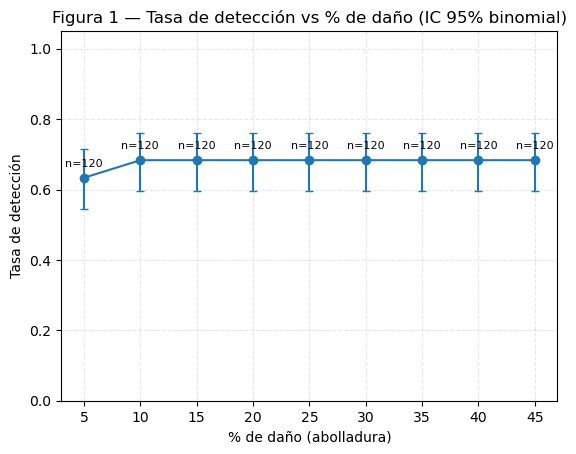

In [2]:
# ============================================
# Figura 1 — Tasa de detección vs % de daño
# (con IC binomial 95% tipo Wilson)
# ============================================

# --- Imports
import math
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt

# --- Ruta del CSV (ajústala si es necesario)
CSV_PATH = "todos_los_resultados_csv.csv"  # o "/mnt/data/todos_los_resultados_csv.csv"

# --- Cargar datos
df = pd.read_csv(CSV_PATH)

# --- Preprocesamiento
# A) % de daño a numérico
df["Porcentaje"] = pd.to_numeric(df["Porcentaje"], errors="coerce")

# B) Convertir DeteccionOK a 0/1 de forma robusta
def deteccion_to_bin(x):
    if pd.isna(x):
        return np.nan
    s = str(x).strip().lower()
    mapa = {
        "verdadero": 1, "true": 1, "1": 1, "si": 1, "sí": 1, "y": 1, "yes": 1,
        "falso": 0, "false": 0, "0": 0, "no": 0, "n": 0
    }
    return mapa.get(s, np.nan)

df["DetOK_bin"] = df["DeteccionOK"].apply(deteccion_to_bin)
df = df.dropna(subset=["Porcentaje", "DetOK_bin"])
df["DetOK_bin"] = df["DetOK_bin"].astype(int)

# --- Función: intervalo de Wilson (IC 95% por defecto)
def wilson_ci(hits: int, n: int, conf: float = 0.95):
    if n == 0:
        return (np.nan, np.nan)
    # z para el nivel de confianza (aprox. 1.96 para 95%)
    z = 1.959963984540054 if abs(conf - 0.95) < 1e-9 else {
        0.90: 1.6448536269514722,
        0.95: 1.959963984540054,
        0.99: 2.5758293035489004
    }.get(conf, 1.959963984540054)
    p = hits / n
    denom = 1.0 + (z**2) / n
    center = (p + (z**2) / (2.0 * n)) / denom
    half = (z / denom) * math.sqrt((p * (1.0 - p) / n) + (z**2) / (4.0 * n**2))
    return (center - half, center + half)

# --- Agregación por % de daño
res = (
    df.groupby("Porcentaje", as_index=False)
      .agg(n=("DetOK_bin", "size"), hits=("DetOK_bin", "sum"))
      .sort_values("Porcentaje")
)
res["rate"] = res["hits"] / res["n"]
cis = res.apply(lambda r: pd.Series(wilson_ci(int(r["hits"]), int(r["n"]), conf=0.95), index=["lo", "hi"]), axis=1)
res = pd.concat([res, cis], axis=1)

# --- (Opcional) Vista rápida de la tabla agregada
try:
    from IPython.display import display
    display(res[["Porcentaje", "n", "hits", "rate", "lo", "hi"]])
except Exception:
    print(res[["Porcentaje", "n", "hits", "rate", "lo", "hi"]])

# --- Gráfica con barras de error (IC 95%)
x = res["Porcentaje"].to_numpy()
y = res["rate"].to_numpy()
yerr = np.vstack([y - res["lo"].to_numpy(), res["hi"].to_numpy() - y])

plt.figure()
plt.errorbar(x, y, yerr=yerr, fmt="o-", capsize=3)
plt.title("Figura 1 — Tasa de detección vs % de daño (IC 95% binomial)")
plt.xlabel("% de daño (abolladura)")
plt.ylabel("Tasa de detección")
plt.ylim(0, 1.05)
plt.grid(True, linestyle="--", alpha=0.3)

# Anotar n sobre cada punto (pequeño)
for xi, yi, ni in zip(x, y, res["n"].astype(int).to_numpy()):
    plt.annotate(f"n={ni}", (xi, yi), textcoords="offset points", xytext=(0, 8), ha="center", fontsize=8)

plt.show()

# --- (Opcional) Guardar tabla de resultados
# res.to_csv("resumen_tasa_deteccion_por_porcentaje.csv", index=False)


## Hallazgos — Figura 1: Tasa de detección vs % de daño (IC 95%)

- **Tasa global (n=1080):** 0.678  
  *IC95%:* 0.649–0.705.

- **Por severidad (n=120 por nivel):**
  - **5%:** 0.633 (76/120) — *IC95%:* 0.544–0.714.
  - **10%–45% (cada nivel):** 0.683 (82/120) — *IC95% por nivel:* 0.596–0.760.  
    - **Agrupado 10–45%:** 0.683 (656/960) — *IC95%:* 0.653–0.712.

### Lecturas clave
- La curva es **casi plana**: de 5% a 45% la probabilidad de detección se mantiene ≈ **0.68**.
- La diferencia entre **5%** y **10–45%** **no es significativa** (los IC se solapan; prueba de dos proporciones p≈0.27).
- El método **no alcanza 0.9** de probabilidad de detección en el rango analizado ⇒ **MDD90 > 45%**.
- Desde 5% ya se supera 0.5 ⇒ **MDD50 < 5%**.

### Mensaje central
> En este agregado, la **severidad de la abolladura (5–45%) no incrementa de forma apreciable** la probabilidad de detección del AG (~0.68). La variación restante parece estar dominada por **tipo/ubicación del elemento** u otros factores (p. ej., pesos de DIs), más que por el % de daño.

### Nota metodológica
- Tasas calculadas con IC binomial **Wilson (95%)** y **n=120** corridas por cada nivel de daño.


## Figura 2 — Sensibilidad por tipo de elemento

**Objetivo.** Comparar la probabilidad de detección del AG entre tipos de miembros (pierna, diagonal/x-brace, viga) a igual severidad de abolladura.

**Cálculo.**
- Para cada tipo \(t\) y severidad \(d\): \(\text{TasaDetección}_t(d)\).
- Ajuste de curvas POD por tipo con regresión logística (con interacción tipo×%).
- Cómputo de **MDD50** y **MDD90** por tipo.
- Métricas de localización por tipo: `N_FalsosPositivos`, `MeanAbsDispersion`.

**Lectura.**
- Curvas más altas → mayor detectabilidad.
- Menor MDD90 → el tipo se detecta confiablemente con menor % de daño.
- Comparar también falsos positivos/dispersiones para un juicio operativo completo.


Resumen de tasas por Tipo y % de daño (primeras filas):


,Tipo,Porcentaje,n,aciertos,tasa,tasa_lo,tasa_hi
0,Beam,5,20,0,0.0,-1.387779e-17,0.16113
1,Beam,10,20,0,0.0,-1.387779e-17,0.16113
2,Beam,15,20,0,0.0,-1.387779e-17,0.16113
3,Beam,20,20,0,0.0,-1.387779e-17,0.16113
4,Beam,25,20,0,0.0,-1.387779e-17,0.16113


Métricas de localización por Tipo y % de daño:


Tipo Porcentaje N_FalsosPositivos                           \
                                       median     mean       std count   
0           Beam          5               9.5  10.8500  8.330508    20   
1           Beam         10               8.0  10.9000  8.521799    20   
2           Beam         15               7.5  10.6000  9.304215    20   
3           Beam         20              10.0  10.6500  8.548776    20   
4           Beam         25              10.5  12.2500  9.951858    20   
5           Beam         30               7.5   9.9000  8.384823    20   
6           Beam         35               9.5   9.6000  6.969105    20   
7           Beam         40               7.5  11.0500  9.310294    20   
8           Beam         45              11.0  11.0500  8.726698    20   
9          Brace          5               1.0   0.9500  0.593211    80   
10         Brace         10               1.0   0.9250  0.568698    80   
11         Brace         15               1.0   0.9250  0.568698    80   
12         Brace         20               1.0   0.7875  0.495390    80   
13         Brace         25               1.0   0.7875  0.495390    80   
14         Brace         30               1.0   0.7875  0.495390    80   
15         Brace         35               1.0   0.7875  0.495390    80   
16         Brace         40               1.0   0.7875  0.495390    80   
17         Brace         45               1.0   0.7875  0.495390    80   
18  Inclined_leg          5               4.0   4.5500  1.761429    20   
19  Inclined_leg         10               3.5   3.3500  2.230766    20   
20  Inclined_leg         15               4.0   6.3500  6.098102    20   
21  Inclined_leg         20               5.0   7.3500  6.922693    20   
22  Inclined_leg         25               7.0   7.4000  8.113666    20   
23  Inclined_leg         30               4.0   7.2000  7.599169    20   
24  Inclined_leg         35               7.0   8.6000  8.191138    20   
25  Inclined_leg         40               7.0   8.3000  7.160565    20   
26  Inclined_leg         45               6.0   8.2500  7.482436    20   

   MeanAbsDispersion                            PromDispersion             \
              median       mean       std count         median       mean   
0          27.567110  25.804067  7.873349    20      27.567110  25.804067   
1          27.595097  25.484601  7.996976    20      27.595097  25.484601   
2          27.343789  26.137014  8.815747    20      27.343789  26.137014   
3          30.689150  27.674463  8.409626    20      30.689150  27.674463   
4          30.085926  27.849421  9.461544    20      30.085926  27.846280   
5          31.424972  27.575212  9.036840    20      31.424972  27.575212   
6          30.285299  28.084538  9.717754    20      30.285299  28.079989   
7          29.051573  25.695518  9.510673    20      29.051573  25.563948   
8          28.376844  26.318168  9.989509    20      28.376844  26.318168   
9           4.255189   5.002158  2.144246    80       3.817794   4.215243   
10          4.150763   4.486775  1.427238    80       3.741300   3.656968   
11          4.201015   4.409400  1.451841    80       3.846935   3.619471   
12          4.292035   4.650567  1.615612    80       3.870535   3.823701   
13          4.270808   4.540748  1.711498    80       3.513208   3.668479   
14          4.209305   4.488226  1.831456    80       3.759518   3.690198   
15          4.239945   4.505013  1.769395    80       3.846330   3.679997   
16          4.209524   4.465105  1.743084    80       3.750360   3.636045   
17          4.220628   4.455753  1.755585    80       3.447191   3.587383   
18         18.786840  18.016607  8.369293    20      18.786840  18.016607   
19         23.861431  19.991088  9.069861    20      23.861431  19.991088   
20         24.359552  21.053699  9.686921    20      24.359552  21.053699   
21         25.449705  22.739601  9.439700    20      25.449705  22.739601   
22         19.679

MDD50/MDD90 por tipo (con IC 95%):


,Tipo,ok_modelo,MDD50,MDD50_lo,MDD50_hi,MDD90,MDD90_lo,MDD90_hi
0,Beam,False,NaN,NaN,NaN,NaN,NaN,NaN
1,Brace,True,4.416918,-597.581702,606.415538,4.926873,-70.57309,80.426836
2,Inclined_leg,True,NaN,NaN,NaN,NaN,NaN,NaN


LR test interacción Tipo×Porcentaje:
  LR=22.810, df=2, p-value=1.114e-05


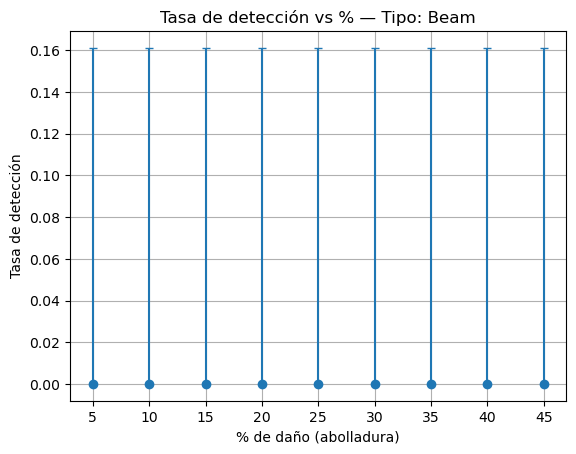

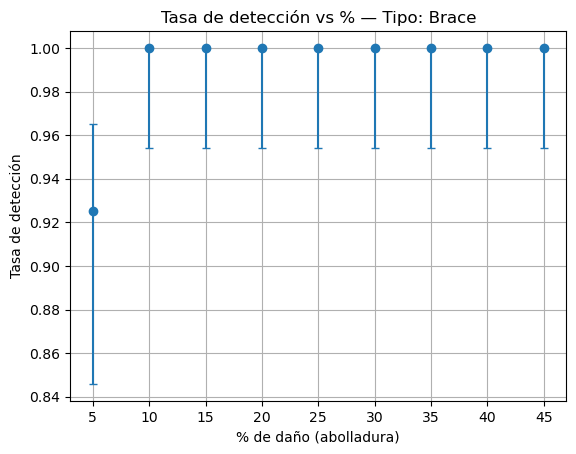

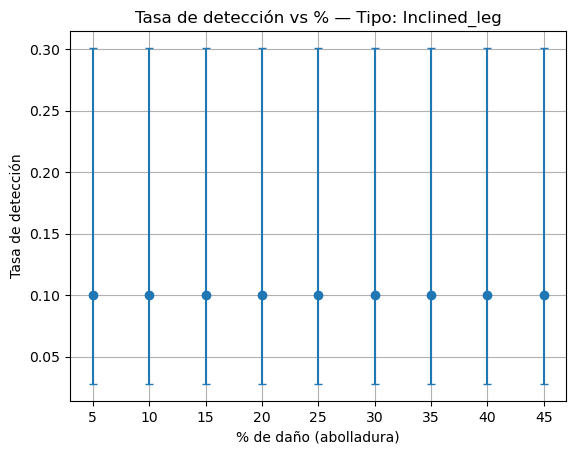

/home/paco/miniforge3/envs/analisis_tesis/lib/python3.9/site-packages/statsmodels/genmod/generalized_linear_model.py:985: FutureWarning: linear keyword is deprecated, use which="linear"
  warnings.warn(msg, FutureWarning)
/home/paco/miniforge3/envs/analisis_tesis/lib/python3.9/site-packages/pandas/core/arraylike.py:399: RuntimeWarning: overflow encountered in exp
  result = getattr(ufunc, method)(*inputs, **kwargs)


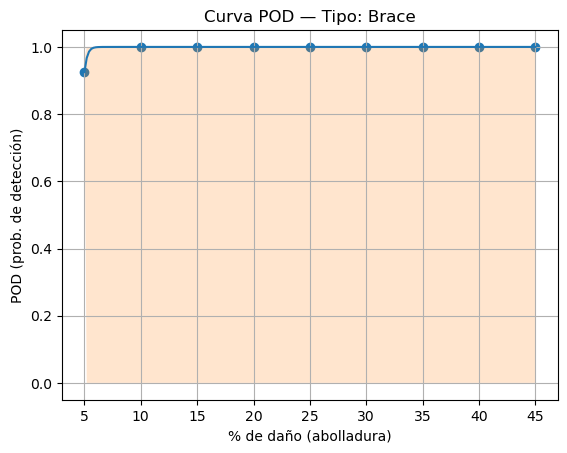

/home/paco/miniforge3/envs/analisis_tesis/lib/python3.9/site-packages/statsmodels/genmod/generalized_linear_model.py:985: FutureWarning: linear keyword is deprecated, use which="linear"
  warnings.warn(msg, FutureWarning)


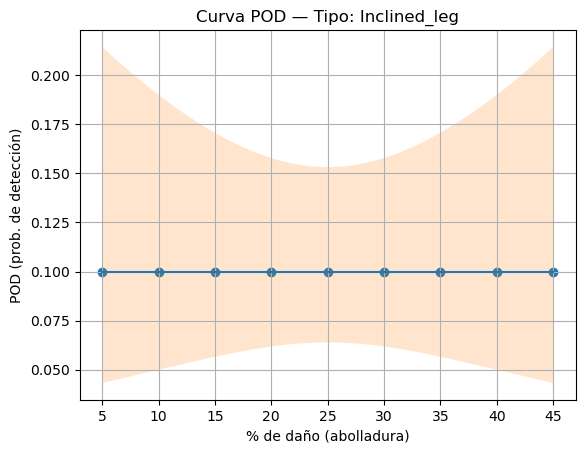

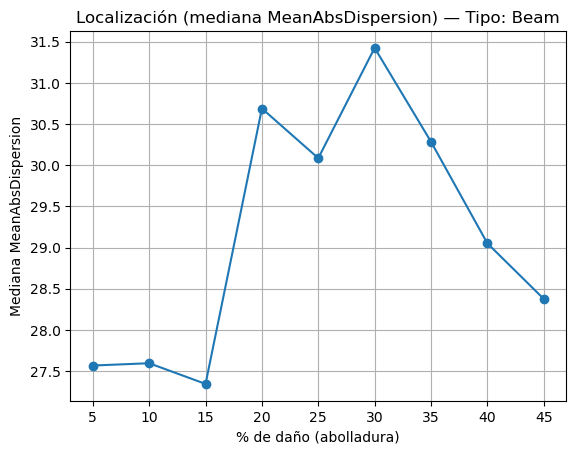

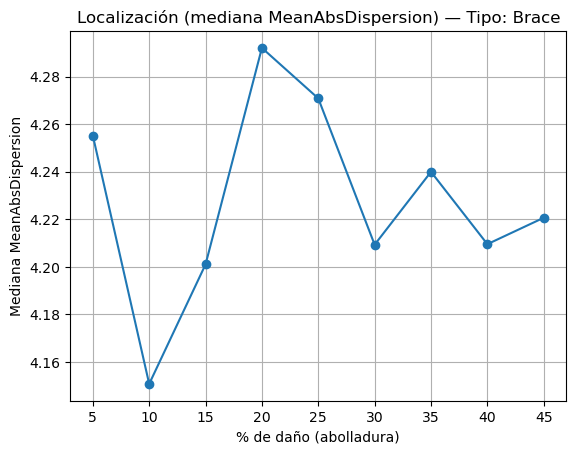

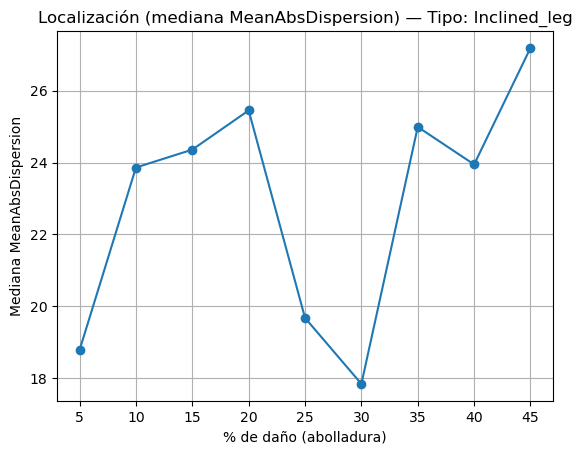

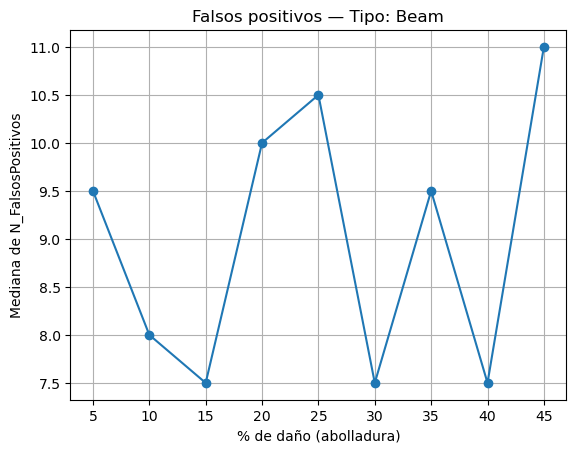

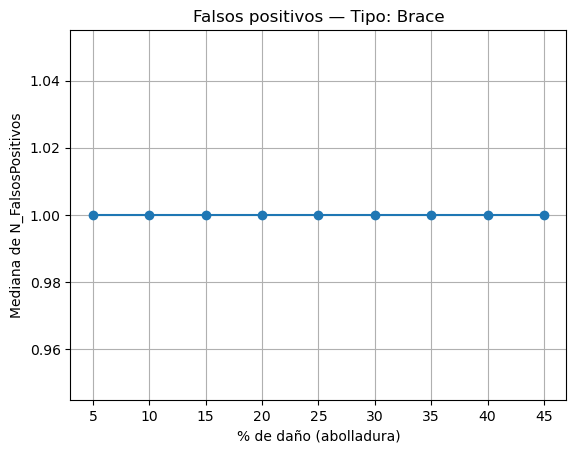

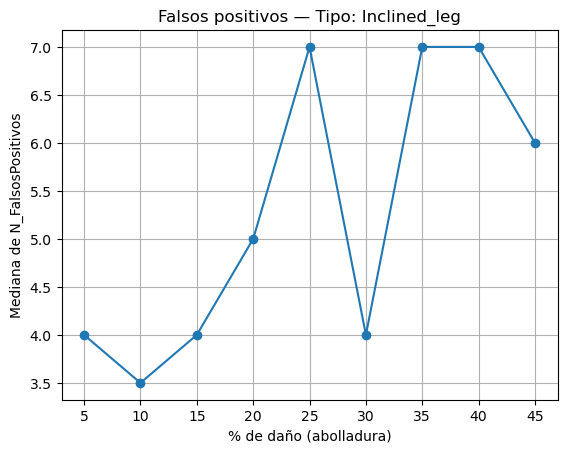

In [4]:
# ---------------------------------------------
# Punto 2 — Sensibilidad por tipo de elemento
# Requiere: pandas, numpy, statsmodels, matplotlib
# ---------------------------------------------
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import statsmodels.api as sm
import statsmodels.formula.api as smf

# === Configura la ruta a tu CSV ===
PATH_CSV = "todos_los_resultados_csv.csv"   # cámbialo si es necesario

# -------------------------
# 1) Cargar y preprocesar
# -------------------------
df = pd.read_csv(PATH_CSV)

# Normaliza nombre de columna de tipo
col_tipo = "Tipo_elemento_a_buscar"
if col_tipo not in df.columns:
    raise ValueError(f"No encuentro la columna '{col_tipo}' en el CSV.")

# Convertir DeteccionOK a 0/1 (acepta VERDADERO/FALSO, True/False, 1/0)
def to_binary(x):
    if isinstance(x, str):
        x_up = x.strip().upper()
        if x_up in ("VERDADERO", "TRUE", "1", "SI", "SÍ"):
            return 1
        if x_up in ("FALSO", "FALSE", "0", "NO"):
            return 0
    if isinstance(x, (int, float)) and x in (0,1):
        return int(x)
    if isinstance(x, bool):
        return int(x)
    # Si no coincide, intenta cast
    try:
        return int(x)
    except Exception:
        return np.nan

df["DetOK"] = df["DeteccionOK"].apply(to_binary)
if df["DetOK"].isna().any():
    print("Aviso: Hay filas con DeteccionOK no interpretable; se eliminarán para este análisis.")
    df = df.dropna(subset=["DetOK"])

# Asegura numéricos
df["Porcentaje"] = pd.to_numeric(df["Porcentaje"], errors="coerce")
df["N_FalsosPositivos"] = pd.to_numeric(df["N_FalsosPositivos"], errors="coerce")
for c in ["MeanAbsDispersion","PromDispersion","StdDispersion"]:
    if c in df.columns:
        df[c] = pd.to_numeric(df[c], errors="coerce")

df = df.dropna(subset=["Porcentaje", col_tipo])

# Renombra por comodidad
df = df.rename(columns={col_tipo: "Tipo"})

# -------------------------------------------
# 2) Tasa de detección por Tipo y Porcentaje
#    + Intervalos de confianza (Wilson 95%)
# -------------------------------------------
def wilson_ci(successes, n, z=1.96):
    if n == 0:
        return (np.nan, np.nan)
    p = successes / n
    denom = 1 + z**2 / n
    center = (p + z**2/(2*n)) / denom
    margin = (z * np.sqrt((p*(1-p)/n) + (z**2)/(4*n**2))) / denom
    return (center - margin, center + margin)

grp = df.groupby(["Tipo", "Porcentaje"], as_index=False).agg(
    n=("DetOK","size"),
    aciertos=("DetOK","sum")
)
grp["tasa"] = grp["aciertos"] / grp["n"]
cis = grp.apply(lambda r: wilson_ci(r["aciertos"], r["n"]), axis=1)
grp["tasa_lo"] = [ci[0] for ci in cis]
grp["tasa_hi"] = [ci[1] for ci in cis]

print("Resumen de tasas por Tipo y % de daño (primeras filas):")
display(grp.head())

# ------------------------------------------------------
# 3) Métricas de localización por tipo y severidad (op.)
# ------------------------------------------------------
loc_cols = [c for c in ["N_FalsosPositivos","MeanAbsDispersion","PromDispersion","StdDispersion"] if c in df.columns]
if loc_cols:
    loc = df.groupby(["Tipo","Porcentaje"], as_index=False)[loc_cols].agg(["median","mean","std","count"])
    print("Métricas de localización por Tipo y % de daño:")
    display(loc)

# ----------------------------------------------------
# 4) Ajuste de curvas POD por tipo (GLM Binomial logit)
#    y MDD50/MDD90 con CIs (delta method)
# ----------------------------------------------------
def fit_logit_for_type(sub):
    # GLM logit: DetOK ~ Porcentaje
    # Nota: si no hay variación en DetOK o en Porcentaje, puede fallar
    m = smf.glm("DetOK ~ Porcentaje", data=sub, family=sm.families.Binomial())
    res = m.fit()
    return res

def logit(p):
    p = np.clip(p, 1e-6, 1-1e-6)
    return np.log(p/(1-p))

def mdd_and_ci(res, p=0.5, z=1.96):
    # d = (logit(p) - a) / b , con a=intercepto, b=péndiente
    a = res.params.get("Intercept", np.nan)
    b = res.params.get("Porcentaje", np.nan)
    if np.isnan(a) or np.isnan(b) or abs(b) < 1e-12:
        return dict(MDD=np.nan, lo=np.nan, hi=np.nan)

    L = logit(p)
    d = (L - a) / b

    # Delta method
    cov = res.cov_params()
    var_a = cov.loc["Intercept","Intercept"]
    var_b = cov.loc["Porcentaje","Porcentaje"]
    cov_ab = cov.loc["Intercept","Porcentaje"]

    dd_da = -1.0 / b
    dd_db = -(L - a) / (b**2)  # = -d/b

    var_d = (dd_da**2)*var_a + (dd_db**2)*var_b + 2*dd_da*dd_db*cov_ab
    se_d = np.sqrt(max(var_d, 0.0))
    lo = d - z*se_d
    hi = d + z*se_d
    return dict(MDD=d, lo=lo, hi=hi)

tipos = sorted(df["Tipo"].unique())
resultados = []

for t in tipos:
    sub = df[df["Tipo"]==t].copy()
    # Chequeos mínimos
    if sub["DetOK"].nunique() < 2 or sub["Porcentaje"].nunique() < 2:
        resultados.append({
            "Tipo": t, "ok_modelo": False,
            "MDD50": np.nan, "MDD50_lo": np.nan, "MDD50_hi": np.nan,
            "MDD90": np.nan, "MDD90_lo": np.nan, "MDD90_hi": np.nan
        })
        continue
    try:
        res = fit_logit_for_type(sub)
        m50 = mdd_and_ci(res, p=0.50)
        m90 = mdd_and_ci(res, p=0.90)
        resultados.append({
            "Tipo": t, "ok_modelo": True,
            "MDD50": m50["MDD"], "MDD50_lo": m50["lo"], "MDD50_hi": m50["hi"],
            "MDD90": m90["MDD"], "MDD90_lo": m90["lo"], "MDD90_hi": m90["hi"]
        })
    except Exception as e:
        print(f"[{t}] Problema al ajustar GLM:", e)
        resultados.append({
            "Tipo": t, "ok_modelo": False,
            "MDD50": np.nan, "MDD50_lo": np.nan, "MDD50_hi": np.nan,
            "MDD90": np.nan, "MDD90_lo": np.nan, "MDD90_hi": np.nan
        })

tabla_mdd = pd.DataFrame(resultados)
print("MDD50/MDD90 por tipo (con IC 95%):")
display(tabla_mdd.sort_values("Tipo"))

# ---------------------------------------------------------
# 5) (Opcional) Modelo conjunto con interacción Tipo×%daño
#     Para contrastar diferencias de nivel/pendiente
# ---------------------------------------------------------
try:
    # Convierte Tipo a categórica explícita
    df["Tipo"] = df["Tipo"].astype("category")
    m_sin_inter = smf.glm("DetOK ~ Porcentaje + C(Tipo)", data=df, family=sm.families.Binomial()).fit()
    m_con_inter = smf.glm("DetOK ~ Porcentaje * C(Tipo)", data=df, family=sm.families.Binomial()).fit()
    lr = 2*(m_con_inter.llf - m_sin_inter.llf)
    from scipy.stats import chi2
    df_diff = m_con_inter.df_model - m_sin_inter.df_model
    pval = chi2.sf(lr, df_diff)
    print("LR test interacción Tipo×Porcentaje:")
    print(f"  LR={lr:.3f}, df={df_diff}, p-value={pval:.4g}")
except Exception as e:
    print("No se pudo ajustar el modelo conjunto con interacción:", e)

# ------------------------------------------
# 6) Gráficas (una figura por cada métrica)
# ------------------------------------------

# 6.1 Tasa de detección por Tipo (puntos con barras de CI)
for t in tipos:
    sub = grp[grp["Tipo"]==t].sort_values("Porcentaje")
    if sub.empty: 
        continue
    plt.figure()
    plt.errorbar(sub["Porcentaje"], sub["tasa"], 
                 yerr=[sub["tasa"]-sub["tasa_lo"], sub["tasa_hi"]-sub["tasa"]],
                 fmt='o', capsize=3)
    plt.xlabel("% de daño (abolladura)")
    plt.ylabel("Tasa de detección")
    plt.title(f"Tasa de detección vs % — Tipo: {t}")
    plt.grid(True)
    plt.show()

# 6.2 Curva POD por tipo (ajuste logístico + puntos empíricos)
for t in tipos:
    sub_raw = df[df["Tipo"]==t]
    sub = grp[grp["Tipo"]==t].sort_values("Porcentaje")
    if sub.empty or sub_raw["DetOK"].nunique() < 2 or sub_raw["Porcentaje"].nunique() < 2:
        continue
    try:
        res = fit_logit_for_type(sub_raw)
        xs = np.linspace(sub_raw["Porcentaje"].min(), sub_raw["Porcentaje"].max(), 200)
        X = sm.add_constant(pd.DataFrame({"Porcentaje": xs}))
        # Predicción (media y CI aprox. por enlace)
        pred_lin = res.predict(X, linear=True)
        pred_mu  = 1/(1+np.exp(-pred_lin))
        # Aproximación de IC por enlace con var(Xb)
        cov = res.cov_params().values
        # Varianza de Xb = X * Cov * X^T (diagonal)
        Xt = X.values
        var_lin = np.sum(Xt @ cov * Xt, axis=1)
        se_lin = np.sqrt(np.maximum(var_lin, 0.0))
        z = 1.96
        lo_lin = pred_lin - z*se_lin
        hi_lin = pred_lin + z*se_lin
        lo = 1/(1+np.exp(-lo_lin))
        hi = 1/(1+np.exp(-hi_lin))

        plt.figure()
        # puntos empíricos
        plt.scatter(sub["Porcentaje"], sub["tasa"])
        # curva POD
        plt.plot(xs, pred_mu)
        # banda de confianza
        plt.fill_between(xs, lo, hi, alpha=0.2, linewidth=0)
        plt.xlabel("% de daño (abolladura)")
        plt.ylabel("POD (prob. de detección)")
        plt.title(f"Curva POD — Tipo: {t}")
        plt.grid(True)
        plt.show()
    except Exception as e:
        print(f"[{t}] No se pudo graficar la curva POD:", e)

# 6.3 Métricas de localización vs % por tipo (si existen)
if "MeanAbsDispersion" in df.columns:
    for t in tipos:
        sub = df[df["Tipo"]==t].groupby("Porcentaje", as_index=False)["MeanAbsDispersion"].median()
        if sub.empty: 
            continue
        plt.figure()
        plt.plot(sub["Porcentaje"], sub["MeanAbsDispersion"], marker="o")
        plt.xlabel("% de daño (abolladura)")
        plt.ylabel("Mediana MeanAbsDispersion")
        plt.title(f"Localización (mediana MeanAbsDispersion) — Tipo: {t}")
        plt.grid(True)
        plt.show()

# 6.4 Falsos positivos vs % por tipo (mediana)
for t in tipos:
    sub = df[df["Tipo"]==t].groupby("Porcentaje", as_index=False)["N_FalsosPositivos"].median()
    if sub.empty:
        continue
    plt.figure()
    plt.plot(sub["Porcentaje"], sub["N_FalsosPositivos"], marker="o")
    plt.xlabel("% de daño (abolladura)")
    plt.ylabel("Mediana de N_FalsosPositivos")
    plt.title(f"Falsos positivos — Tipo: {t}")
    plt.grid(True)
    plt.show()
